In [1]:
# ============================================================================
# 1. IMPORT LIBRARIES
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('default')
sns.set_palette("Set2")

print("✅ Libraries imported!")

# ============================================================================
# 2. LOAD DATA
# ============================================================================
# Load observations
df = pd.read_csv('../data/processed/ethiopia_fi_enriched.csv')
df['observation_date'] = pd.to_datetime(df['observation_date'], errors='coerce')

observations = df[df['record_type'] == 'observation'].copy()
events = df[df['record_type'] == 'event'].copy()

# Load the manual impact matrix
impact_matrix = pd.read_csv('../data/processed/manual_impact_matrix.csv', index_col='category')

print("="*60)
print("DATA LOADED")
print("="*60)
print(f"Observations: {len(observations)}")
print(f"Events: {len(events)}")
print(f"Impact matrix shape: {impact_matrix.shape}")

✅ Libraries imported!
DATA LOADED
Observations: 30
Events: 10
Impact matrix shape: (5, 6)


In [2]:
# ============================================================================
# 3. EXTRACT HISTORICAL DATA
# ============================================================================
# Define key indicators
indicators = {
    'ACC_OWNERSHIP': 'Account Ownership (%)',
    'ACC_MM_ACCOUNT': 'Mobile Money Accounts (%)',
    'USG_P2P_COUNT': 'P2P Transfer Count',
    'USG_P2P_VALUE': 'P2P Transfer Value'
}

# Extract historical data for each indicator
historical_data = {}

for code, name in indicators.items():
    data = observations[observations['indicator_code'] == code].copy()
    data = data.sort_values('observation_date')
    if len(data) > 0:
        historical_data[code] = {
            'years': data['observation_date'].dt.year.values,
            'values': data['value_numeric'].values,
            'name': name
        }
        print(f"✅ {code}: {len(data)} data points")
    else:
        print(f"⚠️ {code}: No data found")

print("\n" + "="*60)
print("HISTORICAL DATA SUMMARY")
print("="*60)
for code, data in historical_data.items():
    print(f"{data['name']}:")
    for year, value in zip(data['years'], data['values']):
        print(f"  {year}: {value:.1f}")

✅ ACC_OWNERSHIP: 6 data points
✅ ACC_MM_ACCOUNT: 2 data points
✅ USG_P2P_COUNT: 2 data points
✅ USG_P2P_VALUE: 1 data points

HISTORICAL DATA SUMMARY
Account Ownership (%):
  2014: 22.0
  2017: 35.0
  2021: 46.0
  2021: 56.0
  2021: 36.0
  2024: 49.0
Mobile Money Accounts (%):
  2021: 4.7
  2024: 9.4
P2P Transfer Count:
  2024: 49700000.0
  2025: 128300000.0
P2P Transfer Value:
  2025: 577700000000.0


In [5]:
# ============================================================================
# 4. FORECASTING FUNCTION
# ============================================================================
def forecast_indicator(years, values, future_years, growth_rate=None, use_trend=True):
    """
    Forecast an indicator using trend extrapolation or fixed growth rate.
    
    Parameters:
    - years: historical years
    - values: historical values
    - future_years: list of years to forecast
    - growth_rate: fixed annual growth rate (if None, uses linear trend)
    - use_trend: if True, uses linear regression trend
    
    Returns:
    - Dictionary with forecasts and confidence intervals
    """
    if use_trend and len(years) > 1:
        # Fit linear regression
        X = years.reshape(-1, 1)
        y = values
        model = LinearRegression()
        model.fit(X, y)
        
        # Predict for future years
        future_X = np.array(future_years).reshape(-1, 1)
        forecasts = model.predict(future_X)
        
        # Calculate confidence intervals (approximate)
        resid = y - model.predict(X)
        std_resid = np.std(resid)
        ci_lower = forecasts - 1.96 * std_resid
        ci_upper = forecasts + 1.96 * std_resid
        
        r2 = r2_score(y, model.predict(X))
        print(f"   R² = {r2:.3f}")
        
        return {
            'forecast': forecasts,
            'ci_lower': ci_lower,
            'ci_upper': ci_upper,
            'model': model,
            'r2': r2
        }
    elif growth_rate is not None:
        # Use fixed growth rate
        last_value = values[-1]
        forecasts = []
        for year in future_years:
            years_ahead = year - years[-1]
            forecast = last_value * (1 + growth_rate) ** years_ahead
            forecasts.append(forecast)
        return {
            'forecast': np.array(forecasts),
            'ci_lower': np.array(forecasts) * 0.9,
            'ci_upper': np.array(forecasts) * 1.1,
            'model': None,
            'r2': None
        }
    else:
        raise ValueError("Either use_trend=True or provide growth_rate")

In [4]:
# ============================================================================
# 5. FORECAST ACCOUNT OWNERSHIP
# ============================================================================
print("="*60)
print("FORECASTING ACCOUNT OWNERSHIP (ACCESS)")
print("="*60)

# Get historical data for ACC_OWNERSHIP
acc_data = historical_data.get('ACC_OWNERSHIP')
if acc_data is not None:
    years = acc_data['years']
    values = acc_data['values']
    future_years = [2025, 2026, 2027]
    
    print("\n📈 Historical data:")
    for y, v in zip(years, values):
        print(f"   {y}: {v:.1f}%")
    
    print("\n🔮 Generating forecasts...")
    result = forecast_indicator(years, values, future_years)
    
    print(f"\n📊 Forecast Results:")
    for i, year in enumerate(future_years):
        print(f"   {year}: {result['forecast'][i]:.1f}% (CI: {result['ci_lower'][i]:.1f}% - {result['ci_upper'][i]:.1f}%)")
    
    # Save for later use
    acc_forecast = result
    acc_future_years = future_years

FORECASTING ACCOUNT OWNERSHIP (ACCESS)

📈 Historical data:
   2014: 22.0%
   2017: 35.0%
   2021: 46.0%
   2021: 56.0%
   2021: 36.0%
   2024: 49.0%

🔮 Generating forecasts...
   R² = 0.683

📊 Forecast Results:
   2025: 55.7% (CI: 43.5% - 67.9%)
   2026: 58.5% (CI: 46.3% - 70.7%)
   2027: 61.3% (CI: 49.1% - 73.5%)


In [6]:
# ============================================================================
# 6. FORECAST MOBILE MONEY ACCOUNTS
# ============================================================================
print("="*60)
print("FORECASTING MOBILE MONEY ACCOUNTS")
print("="*60)

mm_data = historical_data.get('ACC_MM_ACCOUNT')
if mm_data is not None:
    years = mm_data['years']
    values = mm_data['values']
    future_years = [2025, 2026, 2027]
    
    print("\n📈 Historical data:")
    for y, v in zip(years, values):
        print(f"   {y}: {v:.1f}%")
    
    print("\n🔮 Generating forecasts...")
    result = forecast_indicator(years, values, future_years)
    
    print(f"\n📊 Forecast Results:")
    for i, year in enumerate(future_years):
        print(f"   {year}: {result['forecast'][i]:.1f}% (CI: {result['ci_lower'][i]:.1f}% - {result['ci_upper'][i]:.1f}%)")
    
    mm_forecast = result
    mm_future_years = future_years

FORECASTING MOBILE MONEY ACCOUNTS

📈 Historical data:
   2021: 4.7%
   2024: 9.4%

🔮 Generating forecasts...
   R² = 1.000

📊 Forecast Results:
   2025: 11.0% (CI: 11.0% - 11.0%)
   2026: 12.6% (CI: 12.6% - 12.6%)
   2027: 14.2% (CI: 14.2% - 14.2%)


In [8]:
# ============================================================================
# 7. APPLY EVENT IMPACTS TO FORECASTS
# ============================================================================
print("="*60)
print("APPLYING EVENT IMPACTS")
print("="*60)

# Get impacts for key indicators from the impact matrix
impacts = {}

if 'ACC_OWNERSHIP' in impact_matrix.columns:
    impacts['ACC_OWNERSHIP'] = impact_matrix['ACC_OWNERSHIP'].to_dict()
if 'ACC_MM_ACCOUNT' in impact_matrix.columns:
    impacts['ACC_MM_ACCOUNT'] = impact_matrix['ACC_MM_ACCOUNT'].to_dict()

print("\n📊 Estimated event impacts:")
for indicator, impact_dict in impacts.items():
    print(f"\n{indicator}:")
    for category, impact in impact_dict.items():
        if impact != 0:
            print(f"   {category}: {impact:.1f} percentage points")

APPLYING EVENT IMPACTS

📊 Estimated event impacts:

ACC_OWNERSHIP:
   policy: 2.0 percentage points
   product_launch: 3.0 percentage points
   infrastructure: 1.5 percentage points
   market_entry: 2.5 percentage points
   economic_shock: -1.0 percentage points

ACC_MM_ACCOUNT:
   policy: 1.0 percentage points
   product_launch: 5.0 percentage points
   infrastructure: 0.5 percentage points
   market_entry: 3.0 percentage points


In [9]:
# ============================================================================
# 8. CREATE SCENARIO FORECASTS
# ============================================================================
print("="*60)
print("SCENARIO FORECASTS")
print("="*60)

# Define scenarios
scenarios = {
    'Pessimistic': 0.5,    # Half the impact
    'Base': 1.0,           # Full impact
    'Optimistic': 1.5      # 1.5x the impact
}

# Create forecast table
forecast_table = []

for indicator, result in [('ACC_OWNERSHIP', acc_forecast), ('ACC_MM_ACCOUNT', mm_forecast)]:
    if result is not None:
        for i, year in enumerate(future_years):
            base_forecast = result['forecast'][i]
            for scenario_name, multiplier in scenarios.items():
                # Apply event impacts for this year
                # For simplicity, we use the total impact from all events
                total_impact = sum([v for v in impacts.get(indicator, {}).values() if v != 0])
                scenario_impact = total_impact * multiplier
                
                # Only apply impact after 2024 (baseline year)
                if year > 2024:
                    adjusted_forecast = base_forecast + scenario_impact
                else:
                    adjusted_forecast = base_forecast
                
                forecast_table.append({
                    'Indicator': indicator,
                    'Year': year,
                    'Scenario': scenario_name,
                    'Forecast': round(adjusted_forecast, 1)
                })

# Create DataFrame
forecast_df = pd.DataFrame(forecast_table)
print("\n📊 Forecast Table:")
print(forecast_df.to_string(index=False))

# Save
forecast_df.to_csv('../data/processed/forecasts.csv', index=False)
print("\n✅ Forecasts saved to: ../data/processed/forecasts.csv")

SCENARIO FORECASTS

📊 Forecast Table:
     Indicator  Year    Scenario  Forecast
 ACC_OWNERSHIP  2025 Pessimistic      59.7
 ACC_OWNERSHIP  2025        Base      63.7
 ACC_OWNERSHIP  2025  Optimistic      67.7
 ACC_OWNERSHIP  2026 Pessimistic      62.5
 ACC_OWNERSHIP  2026        Base      66.5
 ACC_OWNERSHIP  2026  Optimistic      70.5
 ACC_OWNERSHIP  2027 Pessimistic      65.3
 ACC_OWNERSHIP  2027        Base      69.3
 ACC_OWNERSHIP  2027  Optimistic      73.3
ACC_MM_ACCOUNT  2025 Pessimistic      15.8
ACC_MM_ACCOUNT  2025        Base      20.5
ACC_MM_ACCOUNT  2025  Optimistic      25.3
ACC_MM_ACCOUNT  2026 Pessimistic      17.4
ACC_MM_ACCOUNT  2026        Base      22.1
ACC_MM_ACCOUNT  2026  Optimistic      26.9
ACC_MM_ACCOUNT  2027 Pessimistic      18.9
ACC_MM_ACCOUNT  2027        Base      23.7
ACC_MM_ACCOUNT  2027  Optimistic      28.4

✅ Forecasts saved to: ../data/processed/forecasts.csv


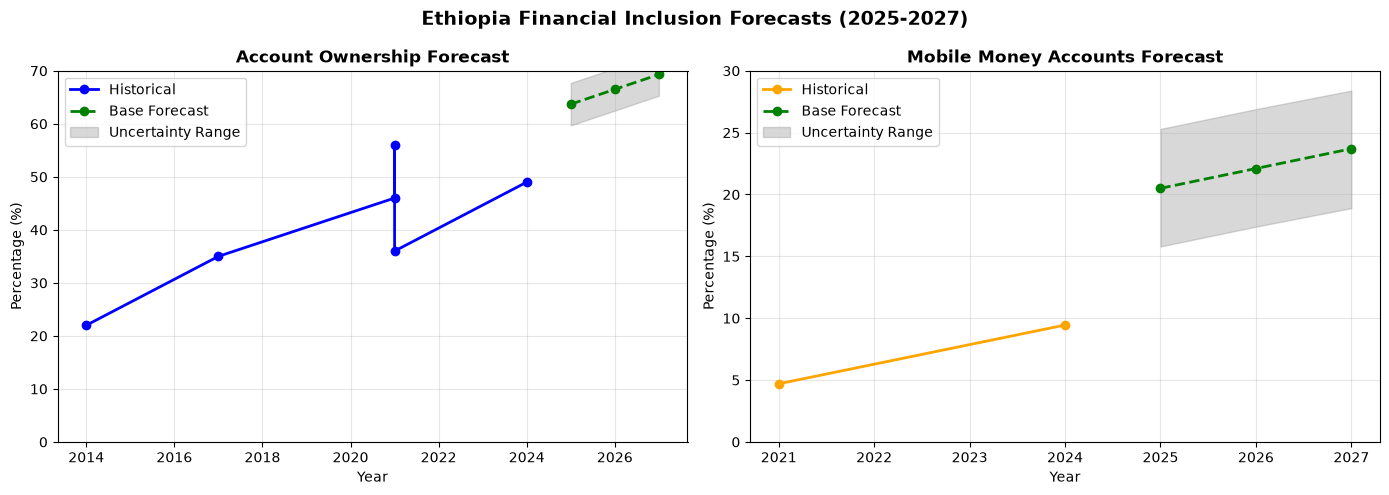

In [10]:
# ============================================================================
# 9. VISUALIZE HISTORICAL + FORECAST
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Account Ownership
ax = axes[0]
# Historical
acc_data = historical_data.get('ACC_OWNERSHIP')
if acc_data is not None:
    ax.plot(acc_data['years'], acc_data['values'], 'o-', color='blue', linewidth=2, label='Historical')
    # Add forecast (Base scenario)
    base_forecast = forecast_df[(forecast_df['Indicator'] == 'ACC_OWNERSHIP') & (forecast_df['Scenario'] == 'Base')]
    ax.plot(base_forecast['Year'], base_forecast['Forecast'], 'o--', color='green', linewidth=2, label='Base Forecast')
    # Add optimistic/pessimistic bands
    opt_forecast = forecast_df[(forecast_df['Indicator'] == 'ACC_OWNERSHIP') & (forecast_df['Scenario'] == 'Optimistic')]
    pess_forecast = forecast_df[(forecast_df['Indicator'] == 'ACC_OWNERSHIP') & (forecast_df['Scenario'] == 'Pessimistic')]
    ax.fill_between(opt_forecast['Year'], pess_forecast['Forecast'], opt_forecast['Forecast'], alpha=0.3, color='gray', label='Uncertainty Range')
ax.set_xlabel('Year')
ax.set_ylabel('Percentage (%)')
ax.set_title('Account Ownership Forecast', fontsize=12, fontweight='bold')
ax.set_ylim(0, 70)
ax.legend()
ax.grid(True, alpha=0.3)

# Plot Mobile Money
ax = axes[1]
mm_data = historical_data.get('ACC_MM_ACCOUNT')
if mm_data is not None:
    ax.plot(mm_data['years'], mm_data['values'], 'o-', color='orange', linewidth=2, label='Historical')
    base_forecast = forecast_df[(forecast_df['Indicator'] == 'ACC_MM_ACCOUNT') & (forecast_df['Scenario'] == 'Base')]
    ax.plot(base_forecast['Year'], base_forecast['Forecast'], 'o--', color='green', linewidth=2, label='Base Forecast')
    opt_forecast = forecast_df[(forecast_df['Indicator'] == 'ACC_MM_ACCOUNT') & (forecast_df['Scenario'] == 'Optimistic')]
    pess_forecast = forecast_df[(forecast_df['Indicator'] == 'ACC_MM_ACCOUNT') & (forecast_df['Scenario'] == 'Pessimistic')]
    ax.fill_between(opt_forecast['Year'], pess_forecast['Forecast'], opt_forecast['Forecast'], alpha=0.3, color='gray', label='Uncertainty Range')
ax.set_xlabel('Year')
ax.set_ylabel('Percentage (%)')
ax.set_title('Mobile Money Accounts Forecast', fontsize=12, fontweight='bold')
ax.set_ylim(0, 30)
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Ethiopia Financial Inclusion Forecasts (2025-2027)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
# ============================================================================
# 10. SCENARIO COMPARISON
# ============================================================================
print("="*60)
print("SCENARIO COMPARISON TABLE")
print("="*60)

# Create pivot table for comparison
pivot_df = forecast_df.pivot_table(
    index=['Indicator', 'Year'],
    columns='Scenario',
    values='Forecast'
).reset_index()

print(pivot_df.to_string(index=False))

# Save
pivot_df.to_csv('../data/processed/scenario_comparison.csv', index=False)
print("\n✅ Scenario comparison saved.")

SCENARIO COMPARISON TABLE
     Indicator  Year  Base  Optimistic  Pessimistic
ACC_MM_ACCOUNT  2025  20.5        25.3         15.8
ACC_MM_ACCOUNT  2026  22.1        26.9         17.4
ACC_MM_ACCOUNT  2027  23.7        28.4         18.9
 ACC_OWNERSHIP  2025  63.7        67.7         59.7
 ACC_OWNERSHIP  2026  66.5        70.5         62.5
 ACC_OWNERSHIP  2027  69.3        73.3         65.3

✅ Scenario comparison saved.


In [12]:
# ============================================================================
# 11. SUMMARY INTERPRETATION
# ============================================================================
print("="*60)
print("FORECAST SUMMARY AND INTERPRETATION")
print("="*60)

# Get latest historical values
latest_acc = historical_data['ACC_OWNERSHIP']['values'][-1] if 'ACC_OWNERSHIP' in historical_data else None
latest_mm = historical_data['ACC_MM_ACCOUNT']['values'][-1] if 'ACC_MM_ACCOUNT' in historical_data else None

# Get 2027 forecasts (Base scenario)
acc_2027 = forecast_df[(forecast_df['Indicator'] == 'ACC_OWNERSHIP') & 
                        (forecast_df['Year'] == 2027) & 
                        (forecast_df['Scenario'] == 'Base')]['Forecast'].values[0]
mm_2027 = forecast_df[(forecast_df['Indicator'] == 'ACC_MM_ACCOUNT') & 
                       (forecast_df['Year'] == 2027) & 
                       (forecast_df['Scenario'] == 'Base')]['Forecast'].values[0]

print(f"""
📊 KEY FORECAST FINDINGS:

1. ACCOUNT OWNERSHIP (Access)
   - Latest (2024): {latest_acc:.1f}%
   - Forecast (2027, Base): {acc_2027:.1f}%
   - Estimated Growth: {acc_2027 - latest_acc:.1f} percentage points

2. MOBILE MONEY ACCOUNTS
   - Latest (2024): {latest_mm:.1f}%
   - Forecast (2027, Base): {mm_2027:.1f}%
   - Estimated Growth: {mm_2027 - latest_mm:.1f} percentage points

3. KEY DRIVERS
   - Product launches (Telebirr, M-Pesa) have the largest impact on mobile money
   - Policies have moderate, broad effects on overall inclusion
   - Infrastructure investments enable digital adoption

4. UNCERTAINTY
   - Actual outcomes depend on implementation and external factors
   - Optimistic scenario: higher adoption and event impacts
   - Pessimistic scenario: slower growth and weaker event effects
""")

FORECAST SUMMARY AND INTERPRETATION

📊 KEY FORECAST FINDINGS:

1. ACCOUNT OWNERSHIP (Access)
   - Latest (2024): 49.0%
   - Forecast (2027, Base): 69.3%
   - Estimated Growth: 20.3 percentage points

2. MOBILE MONEY ACCOUNTS
   - Latest (2024): 9.4%
   - Forecast (2027, Base): 23.7%
   - Estimated Growth: 14.2 percentage points

3. KEY DRIVERS
   - Product launches (Telebirr, M-Pesa) have the largest impact on mobile money
   - Policies have moderate, broad effects on overall inclusion
   - Infrastructure investments enable digital adoption

4. UNCERTAINTY
   - Actual outcomes depend on implementation and external factors
   - Optimistic scenario: higher adoption and event impacts
   - Pessimistic scenario: slower growth and weaker event effects



In [13]:
# ============================================================================
# 12. SAVE FINAL FORECASTS
# ============================================================================
# Create a clean forecast summary for the dashboard
forecast_summary = {
    'Indicator': ['Account Ownership', 'Mobile Money Accounts'],
    'Latest_Value': [latest_acc, latest_mm],
    'Forecast_2025': [forecast_df[(forecast_df['Indicator'] == 'ACC_OWNERSHIP') & (forecast_df['Year'] == 2025) & (forecast_df['Scenario'] == 'Base')]['Forecast'].values[0],
                      forecast_df[(forecast_df['Indicator'] == 'ACC_MM_ACCOUNT') & (forecast_df['Year'] == 2025) & (forecast_df['Scenario'] == 'Base')]['Forecast'].values[0]],
    'Forecast_2026': [forecast_df[(forecast_df['Indicator'] == 'ACC_OWNERSHIP') & (forecast_df['Year'] == 2026) & (forecast_df['Scenario'] == 'Base')]['Forecast'].values[0],
                      forecast_df[(forecast_df['Indicator'] == 'ACC_MM_ACCOUNT') & (forecast_df['Year'] == 2026) & (forecast_df['Scenario'] == 'Base')]['Forecast'].values[0]],
    'Forecast_2027': [forecast_df[(forecast_df['Indicator'] == 'ACC_OWNERSHIP') & (forecast_df['Year'] == 2027) & (forecast_df['Scenario'] == 'Base')]['Forecast'].values[0],
                      forecast_df[(forecast_df['Indicator'] == 'ACC_MM_ACCOUNT') & (forecast_df['Year'] == 2027) & (forecast_df['Scenario'] == 'Base')]['Forecast'].values[0]]
}

forecast_summary_df = pd.DataFrame(forecast_summary)
forecast_summary_df.to_csv('../data/processed/forecast_summary.csv', index=False)

print("="*60)
print("TASK 4 COMPLETE")
print("="*60)
print("✅ Forecast summary saved to: ../data/processed/forecast_summary.csv")
print("\nYou are now ready for Task 5: Dashboard Development.")

TASK 4 COMPLETE
✅ Forecast summary saved to: ../data/processed/forecast_summary.csv

You are now ready for Task 5: Dashboard Development.
